# Alpha Defect Detection

Train a model to predict the Alpha defect (`Y`) from features `X1`..`X49`. The notebook prioritizes zero false negatives (Recall = 100%) and then maximizes precision under that constraint.

In [1]:
# Environment / imports (auto-install missing packages in this kernel)
import os, sys, subprocess, json
def ensure_package(pkg):
    try:
        __import__(pkg)
    except Exception:
        print(f'Installing {pkg} into kernel: {sys.executable}')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])
# Ensure runtime packages (names are PyPI package names)
for p in ['pandas','numpy','scikit-learn','lightgbm','joblib','matplotlib','seaborn']:
    ensure_package(p)
# Now import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except Exception:
    sns = None
    print('Warning: seaborn not installed — plots will use matplotlib. Install with: python -m pip install seaborn')
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import precision_score, recall_score, confusion_matrix, precision_recall_curve, roc_auc_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import joblib
from lightgbm import LGBMClassifier

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

Installing scikit-learn into kernel: C:\Users\ROHIT\Downloads\ML Task\.venv\Scripts\python.exe


In [2]:
# Load dataset files (assumes dataset/ folder present)
train = pd.read_csv('dataset/train.csv')
test = pd.read_csv('dataset/test.csv')
sample_sub = pd.read_csv('dataset/sample_submission.csv')

print('Train shape:', train.shape)
print('Test shape:', test.shape)
print('Sample submission shape:', sample_sub.shape)

train.head()

Train shape: (1352, 51)
Test shape: (339, 50)
Sample submission shape: (10, 2)


,CoilID,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X41,X42,X43,X44,X45,X46,X47,X48,X49,Y
0,487,854.787195,501.088868,414.841484,710.583316,662.072013,656.076977,547.040479,563.653582,495.296785,...,0.201645,0.047960,0.267467,0.052247,-0.893174,0.000000,0.028925,0.000534,0.010797,0.0
1,44,1056.526699,868.083321,622.879982,725.276469,665.235554,647.450550,552.333202,565.105074,493.310075,...,0.644403,0.000000,0.341870,0.153513,25.471899,0.002520,0.033281,0.028349,0.079602,0.0
2,192,1095.648362,668.112517,695.787904,716.773671,662.843475,657.542380,549.863867,546.210823,482.814753,...,0.486502,0.000000,0.202539,0.168192,-25.764196,0.002072,0.033878,0.000000,0.058266,0.0
3,1552,1050.943543,660.340015,440.280245,611.562496,628.081103,561.397721,456.816210,550.103433,378.353283,...,1.198010,0.020787,0.288786,0.329108,1.033840,0.000250,0.045490,0.039004,0.004850,0.0
4,1190,1091.640314,297.363775,842.665620,749.160886,652.992309,615.576656,608.364764,549.756758,487.753140,...,0.237231,0.000841,0.257281,0.112637,-11.130157,0.002376,0.031298,0.003623,0.018434,0.0


In [3]:
# Initial checks
print('Columns sample:', train.columns.tolist()[:6], '... total', len(train.columns))
print('Y distribution:')
print(train['Y'].value_counts())

print('Missing values per column:')
print(train.isna().sum().sort_values(ascending=False).head(20))

Columns sample: ['CoilID', 'X1', 'X2', 'X3', 'X4', 'X5'] ... total 51
Y distribution:
Y
0.0    1286
1.0      66
Name: count, dtype: int64
Missing values per column:
X15       160
X42        31
X48        13
X26         7
X25         6
X24         6
X27         6
X10         6
X23         6
X16         6
X8          1
X21         1
X2          0
CoilID      0
X1          0
X6          0
X5          0
X3          0
X4          0
X18         0
dtype: int64


In [4]:
# Define features, preprocessing pipeline
features = [f'X{i}' for i in range(1,50)]
TARGET = 'Y'
ID = 'CoilID'

X = train[features].copy()
y = train[TARGET].copy()
X_test = test[features].copy()

num_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
preprocessor = ColumnTransformer([('num', num_pipeline, features)])

def build_pipeline(n_estimators=300, lr=0.05):
    clf = LGBMClassifier(n_estimators=n_estimators, learning_rate=lr, random_state=RANDOM_SEED, n_jobs=-1)
    pipe = Pipeline([('preproc', preprocessor), ('clf', clf)])
    return pipe

pipe = build_pipeline()

In [5]:
# Stratified K-Fold OOF probability collection
from sklearn.base import clone
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
oof_preds = np.zeros(len(X))
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    model = build_pipeline()
    model.fit(X_tr, y_tr)
    probs = model.predict_proba(X_val)[:,1]
    oof_preds[val_idx] = probs
    print(f'Fold {fold+1} done')

print('OOF AUC:', roc_auc_score(y, oof_preds))
print('OOF Recall @0.5:', recall_score(y, (oof_preds>=0.5).astype(int)))
print('OOF Precision @0.5:', precision_score(y, (oof_preds>=0.5).astype(int), zero_division=0))

[LightGBM] [Info] Number of positive: 53, number of negative: 1028
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003268 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11792
[LightGBM] [Info] Number of data points in the train set: 1081, number of used features: 49
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.049029 -> initscore=-2.965079
[LightGBM] [Info] Start training from score -2.965079
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

C:\Users\ROHIT\Downloads\ML Task\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 1 done
[LightGBM] [Info] Number of positive: 52, number of negative: 1029
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001170 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11793
[LightGBM] [Info] Number of data points in the train set: 1081, number of used features: 49
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.048104 -> initscore=-2.985099
[LightGBM] [Info] Start training from score -2.985099
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

...

C:\Users\ROHIT\Downloads\ML Task\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 4 done
[LightGBM] [Info] Number of positive: 53, number of negative: 1029
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001068 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11793
[LightGBM] [Info] Number of data points in the train set: 1082, number of used features: 49
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.048983 -> initscore=-2.966051
[LightGBM] [Info] Start training from score -2.966051
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Fold 5 done
OOF AUC: 0.8573448324614732
OOF Recall @0.5: 0.18181818181818182
OOF Precision @0.5: 0.7058823529411765


C:\Users\ROHIT\Downloads\ML Task\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Chosen threshold=0.0000 with precision=0.0488 (Recall=1.0 on OOF)


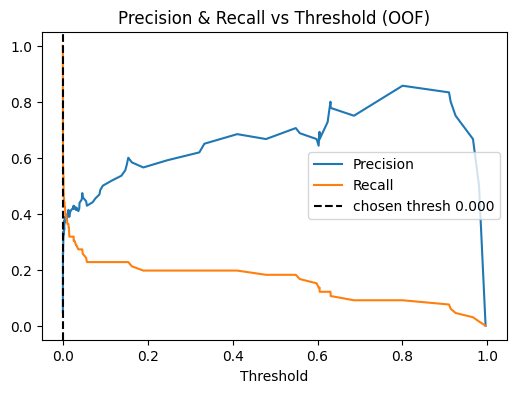

In [6]:
# Threshold search: find highest precision threshold achieving Recall=1.0 on OOF
def find_threshold_for_recall(y_true, probs, target_recall=1.0, n_steps=1001):
    thresholds = np.linspace(0.0, 1.0, n_steps)
    best = None
    for t in thresholds:
        preds = (probs >= t).astype(int)
        r = recall_score(y_true, preds)
        if r >= target_recall:
            p = precision_score(y_true, preds, zero_division=0)
            if best is None or p > best[0]:
                best = (p, t)
    return best

best = find_threshold_for_recall(y, oof_preds, target_recall=1.0)
if best is None:
    print('No threshold found achieving recall=1.0 on OOF; consider resampling or stronger model')
else:
    best_prec, best_thresh = best
    print(f'Chosen threshold={best_thresh:.4f} with precision={best_prec:.4f} (Recall=1.0 on OOF)')

# Optional PR vs threshold plot
precisions, recalls, thresholds = precision_recall_curve(y, oof_preds)
plt.figure(figsize=(6,4))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
if best is not None:
    plt.axvline(best_thresh, color='k', linestyle='--', label=f'chosen thresh {best_thresh:.3f}')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision & Recall vs Threshold (OOF)')
plt.show()

In [7]:
# Retrain on full training set and produce submission
final_model = build_pipeline()
final_model.fit(X, y)
joblib.dump(final_model, 'model_lgbm.joblib')
test_probs = final_model.predict_proba(X_test)[:,1]
chosen_thresh = best_thresh if best is not None else 0.5
test_preds = (test_probs >= chosen_thresh).astype(int)
submission = test[[ID]].copy()
submission['Y'] = test_preds
print('Submission shape:', submission.shape)
submission.to_csv('expected_submission.csv', index=False)
with open('model_threshold.json', 'w') as f:
    json.dump({'threshold': float(chosen_thresh)}, f)
print('Saved expected_submission.csv and model artifacts')

[LightGBM] [Info] Number of positive: 66, number of negative: 1286
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001318 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11797
[LightGBM] [Info] Number of data points in the train set: 1352, number of used features: 49
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.048817 -> initscore=-2.969637
[LightGBM] [Info] Start training from score -2.969637
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

C:\Users\ROHIT\Downloads\ML Task\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Notes
- This notebook enforces Recall=100% on OOF by threshold selection, then applies that threshold to the test set.
- If precision on OOF at Recall=100% is below target (0.9), try resampling (SMOTE), class_weight adjustments, or stronger ensembles.
- Reproducibility: install dependencies in `requirements.txt` and run the notebook in the project root.